In [13]:
# ===============================
# --- HOURLY SALES FORECASTING ---
# ===============================

# --- Imports ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb
import xgboost as xgb
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, r2_score, mean_squared_error, accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from datetime import timedelta

# --- Load and Combine Datasets ---
df_2023 = pd.read_csv('/Users/alexanderdagher/Documents/CafeZal/Coffee-Sales-EDA-and-Prediction-main/mother_data - 2023.csv')
df_2024 = pd.read_csv('/Users/alexanderdagher/Documents/CafeZal/Coffee-Sales-EDA-and-Prediction-main/mother_data - 2024:2025.csv')
df = pd.concat([df_2023, df_2024], ignore_index=True)

# --- Clean and Prepare ---
df['Data'] = pd.to_datetime(df['Data'], format='mixed', dayfirst=True, errors='coerce')
df = df.dropna(subset=['Data'])
df['Datetime'] = df['Data'].dt.floor('H')

# --- Filter for Premuda ---
df = df[df['Punto vendita'] == 'CAFEZAL_PREMUDA']

/var/folders/b0/hvkkd_2d5117jzw6wr3mkw2w0000gn/T/ipykernel_43605/540993075.py:26: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df['Datetime'] = df['Data'].dt.floor('H')


In [14]:
# --- Feature Engineering ---
df['Date'] = df['Data'].dt.date
df['Hour'] = df['Data'].dt.hour
df['Month'] = df['Data'].dt.month
df['Day'] = df['Data'].dt.day
df['Weekday'] = df['Data'].dt.day_name()
df['Weekday_encoded'] = LabelEncoder().fit_transform(df['Weekday'])

# --- Aggregate to Hourly Sales ---
hourly_df = df.groupby(['Date', 'Hour']).agg({'Totale': 'sum'}).reset_index()
hourly_df['Datetime'] = pd.to_datetime(hourly_df['Date'].astype(str)) + pd.to_timedelta(hourly_df['Hour'], unit='h')
hourly_df['Day'] = hourly_df['Datetime'].dt.day
hourly_df['Month'] = hourly_df['Datetime'].dt.month
hourly_df['Weekday'] = hourly_df['Datetime'].dt.day_name()
hourly_df['Weekday_encoded'] = LabelEncoder().fit_transform(hourly_df['Weekday'])

# --- Rolling Features ---
hourly_df['RollingMean_24'] = hourly_df['Totale'].rolling(window=24).mean().fillna(method='bfill')
hourly_df['RollingStd_24'] = hourly_df['Totale'].rolling(window=24).std().fillna(method='bfill')
hourly_df['Lag_1'] = hourly_df['Totale'].shift(1).fillna(method='bfill')

# --- Features and Target ---
X = hourly_df[['Hour', 'Day', 'Month', 'Weekday_encoded', 'RollingMean_24', 'RollingStd_24', 'Lag_1']]
y = hourly_df['Totale']

/var/folders/b0/hvkkd_2d5117jzw6wr3mkw2w0000gn/T/ipykernel_43605/971156640.py:18: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  hourly_df['RollingMean_24'] = hourly_df['Totale'].rolling(window=24).mean().fillna(method='bfill')
/var/folders/b0/hvkkd_2d5117jzw6wr3mkw2w0000gn/T/ipykernel_43605/971156640.py:19: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  hourly_df['RollingStd_24'] = hourly_df['Totale'].rolling(window=24).std().fillna(method='bfill')
/var/folders/b0/hvkkd_2d5117jzw6wr3mkw2w0000gn/T/ipykernel_43605/971156640.py:20: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  hourly_df['Lag_1'] = hourly_df['Totale'].shift(1).fillna(method='bfill')


In [15]:
# --- Cross-Validation ---
kf = KFold(n_splits=5, shuffle=True, random_state=42)
rf = RandomForestRegressor(n_estimators=1000, random_state=42, n_jobs=-1)
cv_scores = cross_val_score(rf, X, y, cv=kf, scoring='r2')
print("Random Forest R² CV Scores:", cv_scores)
print("Average R²:", np.mean(cv_scores))
print("Standard Deviation:", np.std(cv_scores))

# --- Train/Test Split and Training ---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
rf_model = RandomForestRegressor(n_estimators=1000, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

Random Forest R² CV Scores: [0.56856798 0.54776575 0.51728795 0.56881032 0.53190251]
Average R²: 0.54686690285015
Standard Deviation: 0.020258851729371835


RandomForestRegressor(n_estimators=1000, n_jobs=-1, random_state=42)

In [16]:
# --- Evaluate ---
y_pred_train = rf_model.predict(X_train)
y_pred_test = rf_model.predict(X_test)

print("\nRandom Forest Performance (Premuda - Hourly)")
print("---------------------------------------------")
print(f"Train R² Score: {r2_score(y_train, y_pred_train):.4f}")
print(f"Train RMSE: {np.sqrt(mean_squared_error(y_train, y_pred_train)):.2f}")
print(f"Train MAE: {mean_absolute_error(y_train, y_pred_train):.2f}")
print()
print(f"Test R² Score: {r2_score(y_test, y_pred_test):.4f}")
print(f"Test RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_test)):.2f}")
print(f"Test MAE: {mean_absolute_error(y_test, y_pred_test):.2f}")


Random Forest Performance (Premuda - Hourly)
---------------------------------------------
Train R² Score: 0.9379
Train RMSE: 26.69
Train MAE: 18.68

Test R² Score: 0.5673
Test RMSE: 68.26
Test MAE: 49.56


/var/folders/b0/hvkkd_2d5117jzw6wr3mkw2w0000gn/T/ipykernel_43605/3996641292.py:2: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  april_hours = pd.date_range(start='2025-04-01', end='2025-04-30 23:00:00', freq='H')


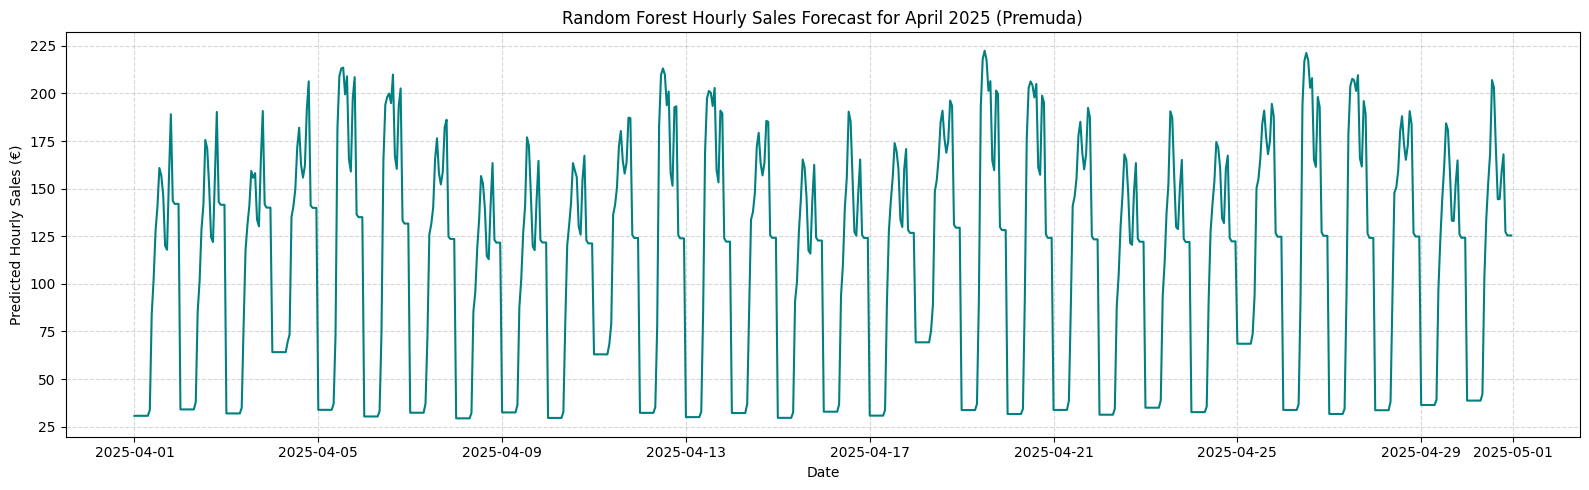

In [17]:
# --- APRIL FORECASTING ---
april_hours = pd.date_range(start='2025-04-01', end='2025-04-30 23:00:00', freq='H')
april_df = pd.DataFrame({'Datetime': april_hours})
april_df['Date'] = april_df['Datetime'].dt.date
april_df['Hour'] = april_df['Datetime'].dt.hour
april_df['Day'] = april_df['Datetime'].dt.day
april_df['Month'] = april_df['Datetime'].dt.month
april_df['Weekday'] = april_df['Datetime'].dt.day_name()
april_df['Weekday_encoded'] = LabelEncoder().fit_transform(april_df['Weekday'])

# Fill rolling stats with recent data
april_df['RollingMean_24'] = hourly_df['RollingMean_24'].iloc[-1]
april_df['RollingStd_24'] = hourly_df['RollingStd_24'].iloc[-1]
april_df['Lag_1'] = hourly_df['Totale'].iloc[-1]

# --- Predict April Hourly Sales ---
X_april = april_df[['Hour', 'Day', 'Month', 'Weekday_encoded', 'RollingMean_24', 'RollingStd_24', 'Lag_1']]
april_df['Predicted_Sales'] = rf_model.predict(X_april)

# --- Plot Forecast ---
plt.figure(figsize=(16, 5))
plt.plot(april_df['Datetime'], april_df['Predicted_Sales'], color='teal')
plt.title("Random Forest Hourly Sales Forecast for April 2025 (Premuda)")
plt.xlabel("Date")
plt.ylabel("Predicted Hourly Sales (€)")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()



✅ Hourly Peak Classification Metrics (Improved Model)
--------------------------------------------------------
Train Accuracy: 0.7527697677948095
Train Precision: 0.43587628865979383
Train Recall: 0.8019726858877086
Train F1: 0.564787603526583
Test Accuracy: 0.7441966317705963
Test Precision: 0.42412935323383083
Test Recall: 0.775
Test F1: 0.5482315112540193
F1 Cross-Validation Scores: [0.46072187 0.38390967 0.12244898 0.48242188 0.35782195]
Average F1: 0.3614648689195853


/var/folders/b0/hvkkd_2d5117jzw6wr3mkw2w0000gn/T/ipykernel_43605/1096149786.py:62: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  future_hours = pd.date_range(start='2025-04-01', end='2025-04-30 23:00:00', freq='H')


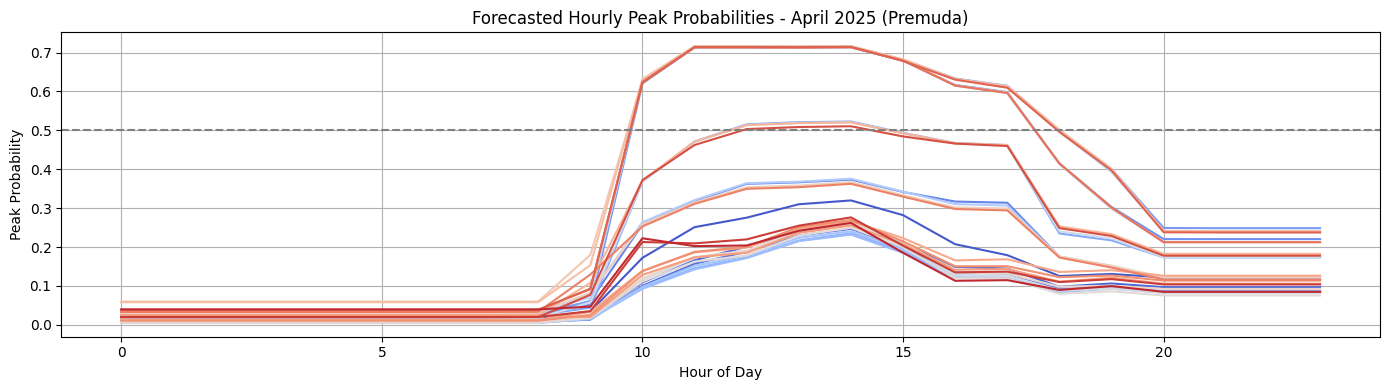


Top Hourly Peak Slots (Prob > 0.5):
           Date  Hour  Peak_Prob
106  2025-04-05    10   0.620601
107  2025-04-05    11   0.713203
108  2025-04-05    12   0.713203
109  2025-04-05    13   0.712928
110  2025-04-05    14   0.713317
..          ...   ...        ...
640  2025-04-27    16   0.630208
641  2025-04-27    17   0.609480
660  2025-04-28    12   0.503225
661  2025-04-28    13   0.508430
662  2025-04-28    14   0.510429

[77 rows x 3 columns]


In [19]:
# ==============================
# --- IMPROVED HOURLY PEAK CLASSIFICATION ---
# ==============================

from sklearn.model_selection import StratifiedKFold

# Re-prepare data (in case anything changed)
historical_hourly = df.copy()
historical_hourly['Date'] = historical_hourly['Data'].dt.date
historical_hourly = historical_hourly.groupby(['Date', 'Hour']).agg({'Totale': 'sum'}).reset_index()
historical_hourly['Day'] = pd.to_datetime(historical_hourly['Date']).dt.day
historical_hourly['Month'] = pd.to_datetime(historical_hourly['Date']).dt.month
historical_hourly['Weekday'] = pd.to_datetime(historical_hourly['Date']).dt.day_name()
historical_hourly['Weekday_encoded'] = LabelEncoder().fit_transform(historical_hourly['Weekday'])

# Define peak hour as top 20% of sales
threshold_hour = historical_hourly['Totale'].quantile(0.80)
historical_hourly['Peak_Hour'] = (historical_hourly['Totale'] >= threshold_hour).astype(int)

X_hour = historical_hourly[['Hour', 'Day', 'Month', 'Weekday_encoded']]
y_hour = historical_hourly['Peak_Hour']

# --- Split Data ---
Xh_train, Xh_test, yh_train, yh_test = train_test_split(X_hour, y_hour, test_size=0.25, stratify=y_hour, random_state=42)

# --- Train Improved Classifier ---
clf_hour = RandomForestClassifier(
    n_estimators=300,
    max_depth=6,
    min_samples_split=8,
    min_samples_leaf=4,
    class_weight='balanced',
    random_state=42
)
clf_hour.fit(Xh_train, yh_train)

# --- Evaluate Classifier ---
yh_train_pred = clf_hour.predict(Xh_train)
yh_test_pred = clf_hour.predict(Xh_test)

print("\n✅ Hourly Peak Classification Metrics (Improved Model)")
print("--------------------------------------------------------")
print("Train Accuracy:", accuracy_score(yh_train, yh_train_pred))
print("Train Precision:", precision_score(yh_train, yh_train_pred))
print("Train Recall:", recall_score(yh_train, yh_train_pred))
print("Train F1:", f1_score(yh_train, yh_train_pred))
print("Test Accuracy:", accuracy_score(yh_test, yh_test_pred))
print("Test Precision:", precision_score(yh_test, yh_test_pred))
print("Test Recall:", recall_score(yh_test, yh_test_pred))
print("Test F1:", f1_score(yh_test, yh_test_pred))

# --- Cross-Validation ---
cv_hour_scores = cross_val_score(clf_hour, X_hour, y_hour, cv=5, scoring='f1')
print("F1 Cross-Validation Scores:", cv_hour_scores)
print("Average F1:", np.mean(cv_hour_scores))

# ==============================
# --- PREDICT HOURLY PEAKS FOR APRIL 2025 ---
# ==============================

# 📌 INSERT THIS RIGHT HERE to fix the future_df error!
future_hours = pd.date_range(start='2025-04-01', end='2025-04-30 23:00:00', freq='H')
future_df = pd.DataFrame({'Datetime': future_hours})
future_df['Date'] = future_df['Datetime'].dt.date
future_df['Hour'] = future_df['Datetime'].dt.hour
future_df['Day'] = future_df['Datetime'].dt.day
future_df['Month'] = future_df['Datetime'].dt.month
future_df['Weekday'] = future_df['Datetime'].dt.day_name()
future_df['Weekday_encoded'] = LabelEncoder().fit_transform(future_df['Weekday'])

# Predict peak probability
X_future_hour = future_df[['Hour', 'Day', 'Month', 'Weekday_encoded']]
future_df['Peak_Prob'] = clf_hour.predict_proba(X_future_hour)[:, 1]

# --- Visualization ---
plt.figure(figsize=(14, 4))
sns.lineplot(data=future_df, x='Hour', y='Peak_Prob', hue='Date', palette='coolwarm', legend=False)
plt.axhline(0.5, linestyle='--', color='gray', label='Threshold = 0.5')
plt.title('Forecasted Hourly Peak Probabilities - April 2025 (Premuda)')
plt.xlabel('Hour of Day')
plt.ylabel('Peak Probability')
plt.grid(True)
plt.tight_layout()
plt.show()

# --- Output Top Hourly Slots ---
print("\nTop Hourly Peak Slots (Prob > 0.5):")
print(future_df[future_df['Peak_Prob'] > 0.5][['Date', 'Hour', 'Peak_Prob']])
